<a href="https://colab.research.google.com/github/vidya100804/AI-ML/blob/main/Telugu_Fake_news.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 93.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.2 MB/s eta 0:00:00

===== MACHINE LEARNING MODELS =====

Training XGBoost...
Accuracy : 0.9747
Precision: 0.9626
Recall   : 0.9815
F1 Score : 0.9720

Training Random Forest...
Accuracy : 0.9704
Precision: 0.9432
Recall   : 0.9935
F1 Score : 0.9677

Training Decision Tree...
Accuracy : 0.9174
Precision: 0.8682
Recall   : 0.9608
F1 Score : 0.9122

Training Naive Bayes...
Accuracy : 0.9733
Precision: 0.9472
Recall   : 0.9956
F1 Score : 0.9708

Training Logist

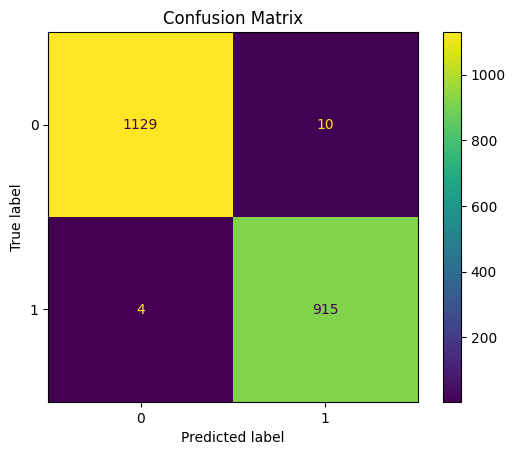

65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step


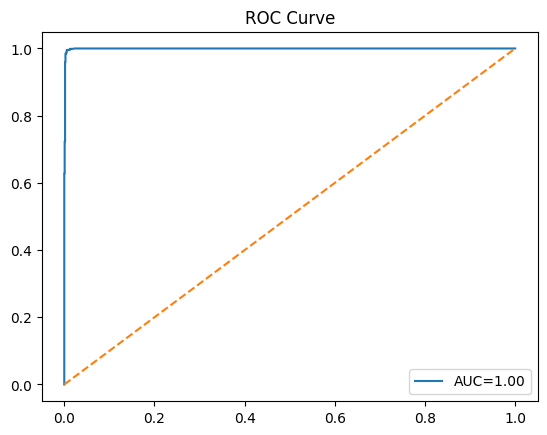

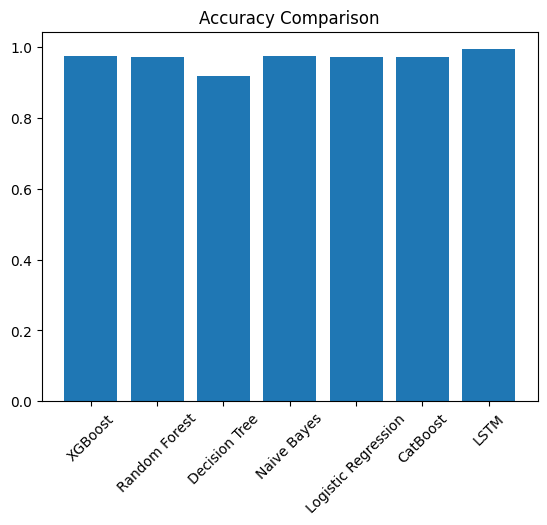

65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step

CSV saved as final_predictions.csv (with Actual vs Predicted)


In [1]:
# ============================================================
# INSTALL LIBRARIES
# ============================================================
!pip install pandas numpy scikit-learn matplotlib xgboost catboost tensorflow pyarrow newspaper3k --quiet


# ============================================================
# IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

import xgboost as xgb
from catboost import CatBoostClassifier

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional


# ============================================================
# LOAD DATA
# ============================================================
train_df = pd.read_parquet('/content/telugu_news_dataset.parquet')
test_df  = pd.read_parquet('/content/telugu_news_test.parquet')


# ============================================================
# PREPROCESSING
# ============================================================
TEXT_COLS = ['title', 'text']
LABEL_COL = 'category'

for col in TEXT_COLS:
    train_df[col] = train_df[col].fillna('')
    test_df[col]  = test_df[col].fillna('')

train_df['combined_text'] = train_df[TEXT_COLS].agg(' '.join, axis=1)
test_df['combined_text']  = test_df[TEXT_COLS].agg(' '.join, axis=1)


def clean_text(text):
    text = re.sub(r'[^ఀ-౿\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['combined_text'] = train_df['combined_text'].apply(clean_text)
test_df['combined_text']  = test_df['combined_text'].apply(clean_text)


# ============================================================
# LABEL CONVERSION
# ============================================================
top_categories = train_df[LABEL_COL].value_counts().nlargest(2).index.tolist()
train_df = train_df[train_df[LABEL_COL].isin(top_categories)]

category_map = {top_categories[0]: 0, top_categories[1]: 1}
train_df['label'] = train_df[LABEL_COL].map(category_map)

X = train_df['combined_text']
y = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# ============================================================
# TF-IDF
# ============================================================
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)


# ============================================================
# MACHINE LEARNING MODELS (WITH FULL METRICS)
# ============================================================
models = {
    'XGBoost': xgb.XGBClassifier(max_depth=10, n_estimators=200),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Decision Tree': DecisionTreeClassifier(max_depth=10),
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'CatBoost': CatBoostClassifier(verbose=0)
}

accuracies = {}
trained_models = {}

print("\n===== MACHINE LEARNING MODELS =====")

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_val_tfidf)

    acc = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    accuracies[name] = acc
    trained_models[name] = model

    print(f"\nTraining {name}...")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


# ============================================================
# LSTM MODEL (WITH METRICS)
# ============================================================
MAX_WORDS = 40000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_LEN)

lstm_model = Sequential([
    Embedding(MAX_WORDS, 128),   # removed warning
    Bidirectional(LSTM(64)),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.fit(X_train_pad, y_train, epochs=3, batch_size=64, verbose=0)

loss, acc = lstm_model.evaluate(X_val_pad, y_val)

y_pred_lstm = (lstm_model.predict(X_val_pad) > 0.5).astype("int32").flatten()

precision = precision_score(y_val, y_pred_lstm)
recall = recall_score(y_val, y_pred_lstm)
f1 = f1_score(y_val, y_pred_lstm)

accuracies["LSTM"] = acc
trained_models["LSTM"] = lstm_model

print("\n===== TRAINING LSTM =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# ============================================================
# BEST MODEL
# ============================================================
best_model = max(accuracies, key=accuracies.get)
print("\nBest Model:", best_model)


# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_val, y_pred_lstm)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()


# ============================================================
# ROC CURVE
# ============================================================
y_prob = lstm_model.predict(X_val_pad)
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()


# ============================================================
# ACCURACY GRAPH
# ============================================================
plt.bar(accuracies.keys(), accuracies.values())
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.show()


# ============================================================
# FINAL CSV
# ============================================================
test_df = test_df[test_df[LABEL_COL].isin(top_categories)]

X_test_final = test_df['combined_text']

X_test_tfidf = tfidf.transform(X_test_final)
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test_final), maxlen=MAX_LEN)

if best_model == "LSTM":
    preds = (lstm_model.predict(X_test_pad) > 0.5).astype("int32").flatten()
else:
    model = trained_models[best_model]
    preds = model.predict(X_test_tfidf)

reverse_map = {0: "Fake", 1: "Real"}

pred_labels = [reverse_map[int(p)] for p in preds]
actual_labels = [reverse_map[category_map[cat]] for cat in test_df[LABEL_COL]]

output_df = pd.DataFrame({
    "News_Text": test_df['combined_text'],
    "Actual_Label": actual_labels,
    "Predicted_Label": pred_labels
})

output_df.to_csv("/content/final_predictions.csv", index=False)

print("\nCSV saved as final_predictions.csv (with Actual vs Predicted)")

In [11]:
import re
import requests
from bs4 import BeautifulSoup
from newspaper import Article
from youtube_transcript_api import YouTubeTranscriptApi
from urllib.parse import urlparse
from pytube import YouTube
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences


# ============================================================
# clean_text (self-contained)
# ============================================================
def clean_text(text):
    text = re.sub(r'[^ఀ-౿\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# ============================================================
# TRUSTED DOMAIN CHECK
# ============================================================
def is_trusted_domain(url):
    trusted_domains = [
        "eenadu.net", "sakshi.com", "andhrajyothy.com",
        "tv9telugu.com", "ntvtelugu.com", "10tv.in",
        "hmtvlive.com", "samayam.com"
    ]
    domain = urlparse(url).netloc.lower()
    return any(td in domain for td in trusted_domains)


# ============================================================
# YOUTUBE TEXT EXTRACTION
# ============================================================
def get_youtube_text(url):
    text = ""
    try:
        video_id = url.split("v=")[-1].split("&")[0]
        try:
            yt = YouTube(url)
            if yt.title:
                text += yt.title + " "
        except:
            pass
        try:
            transcript = YouTubeTranscriptApi.get_transcript(video_id)
            text += " ".join([t['text'] for t in transcript])
        except:
            pass
        if text.strip() == "":
            text = "news video content"
        return text
    except:
        return "news video content"


# ============================================================
# LABEL MAP
# ============================================================
reverse_map = {v: k for k, v in category_map.items()}

def label_to_display(cat_str):
    cat_lower = str(cat_str).lower()
    if any(w in cat_lower for w in ["fake", "false", "inaccurate", "wrong"]):
        return "Prediction: FAKE NEWS"
    else:
        return "Prediction: REAL NEWS"


# ============================================================
# MAIN PREDICTION FUNCTION
# ============================================================
def predict_news(mode, input_data):
    text = ""
    trusted = False

    try:
        if mode == "text":
            text = input_data

        elif mode == "url":
            trusted = is_trusted_domain(input_data)
            try:
                article = Article(input_data)
                article.download()
                article.parse()
                text = article.title + " " + article.text
            except:
                text = ""

            if not text.strip():
                try:
                    headers = {"User-Agent": "Mozilla/5.0"}
                    r = requests.get(input_data, headers=headers, timeout=10)
                    soup = BeautifulSoup(r.content, "html.parser")
                    text = " ".join([p.get_text() for p in soup.find_all("p")])
                except:
                    text = ""

        elif mode == "youtube":
            text = get_youtube_text(input_data)

        if not text.strip():
            return "Prediction: Unable to analyze"

        cleaned = clean_text(text)
        X_input = tfidf.transform([cleaned])

        votes = []

        for name, model in trained_models.items():
            if name != "LSTM":
                votes.append(int(model.predict(X_input)[0]))

        seq = tokenizer.texts_to_sequences([cleaned])
        padded = pad_sequences(seq, maxlen=MAX_LEN)
        lstm_pred = 1 if lstm_model.predict(padded, verbose=0)[0][0] > 0.5 else 0
        votes.append(lstm_pred)

        final = max(set(votes), key=votes.count)

        # ============================================================
        # FINAL DECISION - FIXED LOGIC (moved inside function)
        # ============================================================

        fake_keywords = [
            "fact check", "fake", "false", "misleading",
            "rumor", "rumour", "viral claim",
            "నిలిపివేయబడతాయి", "నిలిపివేయబడతాయని",
            "అసత్య", "నిరాధారమైన", "తప్పుదారి"
        ]

        # Check URL path too (fact-check sites have /fact-check/ in URL)
        url_is_factcheck = "fact-check" in input_data.lower() if mode == "url" else False

        is_fake_content = any(word in text.lower() for word in fake_keywords)

        # FIXED: override regardless of model vote if strong fake signal
        if url_is_factcheck or is_fake_content:
            result = "Prediction: FAKE NEWS"
        elif trusted and final == 1:
            result = "Prediction: REAL NEWS"
        else:
            result = label_to_display(reverse_map[final])

        return result

    except Exception as e:
        return f"Error: {str(e)}"


# ============================================================
# UI HANDLER
# ============================================================
def predict_from_ui(text, url, youtube_url):
    if text:
        return predict_news("text", text)
    elif url:
        return predict_news("url", url)
    elif youtube_url:
        return predict_news("youtube", youtube_url)
    else:
        return "Please enter Text or URL or YouTube URL"


# ============================================================
# UI (UNCHANGED DESIGN)
# ============================================================
interface = gr.Interface(
    fn=predict_from_ui,
    inputs=[
        gr.Textbox(label="Enter Telugu News Text"),
        gr.Textbox(label="Enter News URL"),
        gr.Textbox(label="Enter YouTube URL")
    ],
    outputs=gr.Textbox(label="Result", lines=6),
    title="Telugu News Verifier",
    description="Determine if a piece of news is REAL or FAKE using domain verification and pattern analysis."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://83b2270ed3dca80231.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
